# Monte Carlo for the replicated Ising model on graphons

## Model and temperature convention

Write $J_{ij}=J W_{ij}$, assume the symmetric part of $W$, and set
$W_{ii}=0$ (no loops). Then, self-consistency eq is

$$
m_i=\frac{1}{\nu}\sum_{s=1}^{\nu}\sigma_i^s
    =\frac{2k_i-\nu}{\nu},$$
The Hamiltonian is
$$H_{n,\nu}(\sigma)
  =-\frac{1}{2n\nu^2}\sum_{i,j=1}^{n}
    \sum_{s,t=1}^{\nu}J_{ij}\sigma_i^s\sigma_j^t
  =-\frac{J}{2n}\,m^{\mathsf T}Wm.$$

In [1]:
using Random
using LinearAlgebra
using Statistics
using SparseArrays
using DelimitedFiles
using Test
using Printf

# Optional packages used only for spectra and plots.
const HAS_ARPACK = try
    @eval using Arpack
    true
catch err
    @warn "Arpack is unavailable; large-matrix spectral utilities are disabled." exception=(err, catch_backtrace())
    false
end

const HAS_PLOTS = try
    @eval using Plots
    true
catch err
    @warn "Plots is unavailable; simulations still run, but plotting cells are skipped." exception=(err, catch_backtrace())
    false
end
# Parallelization and explicit check that several threads are available
@info "Julia setup" threads=Threads.nthreads() blas_threads=BLAS.get_num_threads()
# For a threaded temperature scan, BLAS.set_num_threads(1) usually avoids oversubscription.

┌ Info: Julia setup
│   threads = 1
└   blas_threads = 16


## Coupling representations

`MatrixCoupling` handles deterministic graphon discretizations, sampled adjacency matrices, and sparse matrices. `RankOneCoupling` represents
$W_{ij}=u_i u_j$ for $i\ne j$, which includes the power-law graphon $W(x,y)=(xy)^{-\alpha}$. The diagonal is omitted in both cases, as required for a simple graph; this does not affect the continuum graphon operator.

In [2]:
abstract type AbstractCoupling end

struct MatrixCoupling{MT<:AbstractMatrix{Float64}} <: AbstractCoupling
    W::MT
end

struct RankOneCoupling <: AbstractCoupling
    u::Vector{Float64}
end

n_nodes(c::MatrixCoupling) = size(c.W, 1)
n_nodes(c::RankOneCoupling) = length(c.u)

function matrix_coupling(W::AbstractMatrix{<:Real}; symmetrize::Bool=true)
    size(W, 1) == size(W, 2) || throw(ArgumentError("W must be square"))

    A = W isa SparseMatrixCSC ? sparse(Float64.(W)) : Matrix{Float64}(W)
    if symmetrize
        A = 0.5 * (A + transpose(A))
    elseif !issymmetric(A)
        throw(ArgumentError("W must be symmetric, or use symmetrize=true"))
    end

    @inbounds for i in axes(A, 1)
        A[i, i] = 0.0
    end
    A isa SparseMatrixCSC && dropzeros!(A)

    finite_entries = A isa SparseMatrixCSC ? nonzeros(A) : A
    all(isfinite, finite_entries) || throw(ArgumentError("W contains non-finite entries"))
    return MatrixCoupling(A)
end

function rank_one_coupling(u::AbstractVector{<:Real})
    v = Float64.(u)
    all(isfinite, v) || throw(ArgumentError("rank-one weights must be finite"))
    return RankOneCoupling(v)
end

function materialize(c::RankOneCoupling)
    W = c.u * transpose(c.u)
    @inbounds for i in axes(W, 1)
        W[i, i] = 0.0
    end
    return W
end


materialize (generic function with 1 method)

## Graphon and random-graph constructors

- `small_world_kernel` returns the deterministic midpoint discretization
  $W^n\approx W$.
- `sample_w_random` samples a symmetric $W$-random adjacency matrix from a
  probability matrix.
- `power_law_coupling` keeps $W(x,y)=(xy)^{-\alpha}$ in rank-one form.
- `sample_sparse_power_law_coupling` implements the midpoint version of the
  truncation in Eq. (12), samples the sparse graph, and rescales its nonzero
  edges by $\rho_n^{-1}=n^\gamma$. Thus its expectation approaches the
  truncated power-law kernel rather than vanishing with edge density.


In [3]:
midpoint_grid(n::Integer) = ((collect(1:n) .- 0.5) ./ n)

function erdos_renyi_kernel(n::Integer, p::Real)
    0.0 <= p <= 1.0 || throw(ArgumentError("p must lie in [0,1]"))
    W = fill(Float64(p), n, n)
    W[diagind(W)] .= 0.0
    return W
end

function small_world_kernel(n::Integer, p::Real, r::Real)
    0.0 <= p <= 1.0 || throw(ArgumentError("p must lie in [0,1]"))
    0.0 < r <= 0.5 || throw(ArgumentError("r must lie in (0,1/2]"))
    W = zeros(Float64, n, n)
    @inbounds for j in 2:n, i in 1:(j - 1)
        d = abs(i - j) / n
        d = min(d, 1.0 - d)
        wij = d <= r ? 1.0 - p : p
        W[i, j] = wij
        W[j, i] = wij
    end
    return W
end

function sample_w_random(P::AbstractMatrix{<:Real}; seed::Integer=20260830,
                         sparse_output::Bool=false)
    n = size(P, 1)
    size(P, 2) == n || throw(ArgumentError("P must be square"))
    rng = MersenneTwister(seed)

    if sparse_output
        rows = Int[]
        cols = Int[]
        vals = Float64[]
        @inbounds for j in 2:n, i in 1:(j - 1)
            pij = clamp(0.5 * (Float64(P[i, j]) + Float64(P[j, i])), 0.0, 1.0)
            if rand(rng) < pij
                push!(rows, i); push!(cols, j); push!(vals, 1.0)
                push!(rows, j); push!(cols, i); push!(vals, 1.0)
            end
        end
        return sparse(rows, cols, vals, n, n)
    end

    A = zeros(Float64, n, n)
    @inbounds for j in 2:n, i in 1:(j - 1)
        pij = clamp(0.5 * (Float64(P[i, j]) + Float64(P[j, i])), 0.0, 1.0)
        if rand(rng) < pij
            A[i, j] = 1.0
            A[j, i] = 1.0
        end
    end
    return A
end

function power_law_coupling(n::Integer, alpha::Real)
    0.0 < alpha < 0.5 || throw(ArgumentError("alpha must lie in (0,1/2)"))
    x = midpoint_grid(n)
    return rank_one_coupling(x .^ (-Float64(alpha)))
end

power_law_continuum_Tc(alpha::Real, J::Real=1.0) = J / (1.0 - 2.0 * alpha)

function sample_sparse_power_law_coupling(n::Integer, alpha::Real, gamma::Real;
                                           seed::Integer=20260830)
    0.0 < alpha < gamma < 0.5 ||
        throw(ArgumentError("Eq. (12) requires 0 < alpha < gamma < 1/2"))
    rng = MersenneTwister(seed)
    u = midpoint_grid(n) .^ (-Float64(alpha))
    rho = n ^ (-Float64(gamma))
    edge_weight = inv(rho)
    rows = Int[]
    cols = Int[]
    vals = Float64[]

    @inbounds for j in 2:n, i in 1:(j - 1)
        pij = min(1.0, rho * u[i] * u[j])
        if rand(rng) < pij
            push!(rows, i); push!(cols, j); push!(vals, edge_weight)
            push!(rows, j); push!(cols, i); push!(vals, edge_weight)
        end
    end
    return matrix_coupling(sparse(rows, cols, vals, n, n); symmetrize=false)
end


sample_sparse_power_law_coupling (generic function with 1 method)

## State representation

The microscopic configuration enters the Hamiltonian only through $k_i\in\{0,\ldots,\nu\}$, the number of $+1$ spins at node $i$. The vector `m` stores $(2k_i-\nu)/\nu$. For a matrix coupling, `cache` stores $h=(J/n)Wm$; for a rank-one coupling it stores the scalar $q=u^{\mathsf T}m$.

In [4]:
mutable struct ReplicatedGraphonIsing{C<:AbstractCoupling,Cache,RT<:AbstractRNG}
    coupling::C
    n::Int
    nu::Int
    J::Float64
    T::Float64
    convention::Symbol
    up::Vector{Int}
    m::Vector{Float64}
    cache::Cache
    rng::RT
    order::Vector{Int}
end

function initial_counts(rng::AbstractRNG, n::Int, nu::Int, init)
    if init === :random
        up = zeros(Int, n)
        @inbounds for i in 1:n, _ in 1:nu
            up[i] += rand(rng, Bool)
        end
        return up
    elseif init === :plus
        return fill(nu, n)
    elseif init === :minus
        return zeros(Int, n)
    elseif init isa AbstractVector
        length(init) == n || throw(DimensionMismatch("initial profile must have length n"))
        profile = clamp.(Float64.(init), -1.0, 1.0)
        return round.(Int, 0.5 .* nu .* (profile .+ 1.0))
    elseif init isa AbstractMatrix
        size(init) == (n, nu) ||
            throw(DimensionMismatch("microscopic initial state must have size (n, nu)"))
        return vec(sum(init .> 0, dims=2))
    end
    throw(ArgumentError("init must be :random, :plus, :minus, a local profile, or an n-by-nu spin matrix"))
end

function initial_cache(c::MatrixCoupling, m::Vector{Float64}, J::Float64, n::Int)
    h = zeros(Float64, n)
    mul!(h, c.W, m)
    h .*= J / n
    return h
end

initial_cache(c::RankOneCoupling, m::Vector{Float64}, J::Float64, n::Int) = dot(c.u, m)

function ReplicatedGraphonIsing(coupling::AbstractCoupling;
                                nu::Integer=1,
                                J::Real=1.0,
                                T::Real=1.0,
                                convention::Symbol=:manuscript,
                                init=:random,
                                seed::Integer=20260830)
    n = n_nodes(coupling)
    nu > 0 || throw(ArgumentError("nu must be positive"))
    T > 0 || throw(ArgumentError("T must be positive"))
    convention in (:manuscript, :microscopic) ||
        throw(ArgumentError("convention must be :manuscript or :microscopic"))

    rng = MersenneTwister(seed)
    up = initial_counts(rng, n, Int(nu), init)
    m = @. 2.0 * up / nu - 1.0
    cache = initial_cache(coupling, m, Float64(J), n)
    return ReplicatedGraphonIsing(
        coupling, n, Int(nu), Float64(J), Float64(T), convention,
        up, m, cache, rng, collect(1:n),
    )
end

beta_micro(model::ReplicatedGraphonIsing) =
    model.convention === :manuscript ? model.nu / model.T : inv(model.T)


beta_micro (generic function with 1 method)

## Exact fields, energy, and free-energy functional

For $W_{ii}=0$, flipping one selected spin $\sigma_i^s=\sigma$ changes $m_i$ by $\delta=-2\sigma/\nu$ and changes the Hamiltonian by
$$\Delta H=\frac{2\sigma}{\nu}h_i, \qquad h_i=\frac{J}{n}\sum_jW_{ij}m_j.$$
The cached field is updated after each accepted move, so a sequential chain remains exact. The function `mean_field_free_energy` evaluates the manuscript's deterministic free-energy functional.


In [5]:
function add_scaled_column!(y::Vector{Float64}, W::StridedMatrix{Float64},
                            i::Int, a::Float64)
    BLAS.axpy!(a, view(W, :, i), y)
    return y
end

function add_scaled_column!(y::Vector{Float64}, W::SparseMatrixCSC{Float64,Int},
                            i::Int, a::Float64)
    rows = rowvals(W)
    vals = nonzeros(W)
    @inbounds for ptr in nzrange(W, i)
        y[rows[ptr]] += a * vals[ptr]
    end
    return y
end

function add_scaled_column!(y::Vector{Float64}, W::AbstractMatrix{Float64},
                            i::Int, a::Float64)
    @inbounds @simd for j in axes(W, 1)
        y[j] += a * W[j, i]
    end
    return y
end

@inline local_field(model::ReplicatedGraphonIsing{<:MatrixCoupling}, i::Int) = model.cache[i]

@inline function local_field(model::ReplicatedGraphonIsing{<:RankOneCoupling}, i::Int)
    u = model.coupling.u
    return (model.J / model.n) * u[i] * (model.cache - u[i] * model.m[i])
end

function apply_local_change!(model::ReplicatedGraphonIsing{<:MatrixCoupling},
                             i::Int, delta_m::Float64)
    model.m[i] += delta_m
    add_scaled_column!(model.cache, model.coupling.W, i,
                       (model.J / model.n) * delta_m)
    return nothing
end

function apply_local_change!(model::ReplicatedGraphonIsing{<:RankOneCoupling},
                             i::Int, delta_m::Float64)
    model.m[i] += delta_m
    model.cache += model.coupling.u[i] * delta_m
    return nothing
end

hamiltonian(model::ReplicatedGraphonIsing{<:MatrixCoupling}) =
    -0.5 * dot(model.m, model.cache)

function hamiltonian(model::ReplicatedGraphonIsing{<:RankOneCoupling})
    u = model.coupling.u
    diagonal_term = 0.0
    @inbounds @simd for i in eachindex(u)
        diagonal_term += (u[i] * model.m[i])^2
    end
    return -(model.J / (2.0 * model.n)) * (model.cache^2 - diagonal_term)
end

global_magnetization(model::ReplicatedGraphonIsing) = mean(model.m)
local_magnetization(model::ReplicatedGraphonIsing) = copy(model.m)

function interaction_energy(c::MatrixCoupling, m::AbstractVector, J::Real)
    return -(J / (2.0 * length(m))) * dot(m, c.W * m)
end

function interaction_energy(c::RankOneCoupling, m::AbstractVector, J::Real)
    q = dot(c.u, m)
    diagonal_term = sum((c.u[i] * m[i])^2 for i in eachindex(m))
    return -(J / (2.0 * length(m))) * (q^2 - diagonal_term)
end

@inline function binary_entropy(m::Real)
    p = clamp(0.5 * (1.0 + Float64(m)), 0.0, 1.0)
    q = 1.0 - p
    xlogx(x) = iszero(x) ? 0.0 : x * log(x)
    return -xlogx(p) - xlogx(q)
end

function mean_field_free_energy(c::AbstractCoupling, m::AbstractVector,
                                J::Real, T::Real)
    return interaction_energy(c, m, J) - T * sum(binary_entropy, m)
end

function cache_error(model::ReplicatedGraphonIsing{<:MatrixCoupling})
    expected = (model.J / model.n) .* (model.coupling.W * model.m)
    return maximum(abs.(expected .- model.cache))
end

cache_error(model::ReplicatedGraphonIsing{<:RankOneCoupling}) =
    abs(dot(model.coupling.u, model.m) - model.cache)


cache_error (generic function with 2 methods)

## Markov-chain updates

`heatbath_sweep!` visits every node once in random order and redraws its replica count from the exact conditional binomial distribution. Its cost is $O(n^2+n\nu)$ for a dense matrix and $O(n\nu)$ for the rank-one power-law coupling.

`metropolis_sweep!` makes $n\nu$ uniformly selected single-spin proposals, matching the Metropolis-Hastings description in Sec. VI of the manuscript. It is retained as a reference implementation; block heat bath is normally preferable when $\nu>1$.

In [6]:
@inline function logistic_stable(x::Float64)
    if x >= 0.0
        z = exp(-x)
        return inv(1.0 + z)
    end
    z = exp(x)
    return z / (1.0 + z)
end

# Exact and dependency-free. For the intended nu=O(10-100), its cost is small
# compared with a dense field update.
@inline function draw_binomial(rng::AbstractRNG, nu::Int, p::Float64)
    k = 0
    @inbounds for _ in 1:nu
        k += rand(rng) < p
    end
    return k
end

function heatbath_sweep!(model::ReplicatedGraphonIsing)
    shuffle!(model.rng, model.order)
    changed = 0
    beta = beta_micro(model)

    @inbounds for i in model.order
        h = local_field(model, i)
        p_up = logistic_stable(2.0 * beta * h / model.nu)
        old_k = model.up[i]
        new_k = draw_binomial(model.rng, model.nu, p_up)
        if new_k != old_k
            delta_m = 2.0 * (new_k - old_k) / model.nu
            model.up[i] = new_k
            apply_local_change!(model, i, delta_m)
            changed += 1
        end
    end
    return changed, model.n
end

function metropolis_sweep!(model::ReplicatedGraphonIsing;
                           attempts::Int=model.n * model.nu)
    accepted = 0
    beta = beta_micro(model)

    @inbounds for _ in 1:attempts
        i = rand(model.rng, 1:model.n)
        k = model.up[i]
        sigma = rand(model.rng) < k / model.nu ? 1 : -1
        delta_H = 2.0 * sigma * local_field(model, i) / model.nu

        if delta_H <= 0.0 || log(rand(model.rng)) < -beta * delta_H
            model.up[i] -= sigma
            apply_local_change!(model, i, -2.0 * sigma / model.nu)
            accepted += 1
        end
    end
    return accepted, attempts
end

function sweep!(model::ReplicatedGraphonIsing, algorithm::Symbol)
    algorithm === :heatbath && return heatbath_sweep!(model)
    algorithm === :metropolis && return metropolis_sweep!(model)
    throw(ArgumentError("algorithm must be :heatbath or :metropolis"))
end


sweep! (generic function with 1 method)

## Simulation driver and uncertainty estimates

Measurements are separated by `thin` full sweeps. If a `reference` mode is supplied, every sampled local profile is globally sign-aligned to that mode
before averaging; this prevents the $\mathbb{Z}_2$ symmetry from washing out a ferromagnetic or antiferromagnetic profile. The raw signed time series is still retained.


In [7]:
function integrated_autocorrelation_time(x::AbstractVector{<:Real};
                                         maxlag::Int=min(length(x) ÷ 2, 1000))
    n = length(x)
    n < 2 && return 0.5
    y = Float64.(x) .- mean(x)
    c0 = dot(y, y) / n
    iszero(c0) && return 0.5

    tau = 0.5
    for lag in 1:maxlag
        rho = dot(view(y, 1:(n - lag)), view(y, (lag + 1):n)) / ((n - lag) * c0)
        rho <= 0.0 && break
        tau += rho
    end
    return tau
end

function series_statistics(x::AbstractVector{<:Real})
    n = length(x)
    tau = integrated_autocorrelation_time(x)
    ess = min(Float64(n), n / (2.0 * tau))
    sigma = n > 1 ? std(x) : 0.0
    return (mean=mean(x), std=sigma, tau_int=tau,
            effective_samples=ess, stderr=sigma / sqrt(max(ess, 1.0)))
end

function run_chain!(model::ReplicatedGraphonIsing;
                    algorithm::Symbol=:heatbath,
                    burn_sweeps::Int=300,
                    samples::Int=600,
                    thin::Int=1,
                    reference=nothing)
    burn_sweeps >= 0 || throw(ArgumentError("burn_sweeps must be nonnegative"))
    samples > 0 || throw(ArgumentError("samples must be positive"))
    thin > 0 || throw(ArgumentError("thin must be positive"))

    ref = reference === nothing ? nothing : Float64.(reference)
    ref !== nothing && length(ref) != model.n &&
        throw(DimensionMismatch("reference must have length n"))
    ref_norm = ref === nothing ? NaN : norm(ref) * sqrt(model.n)
    ref !== nothing && iszero(ref_norm) && throw(ArgumentError("reference cannot vanish"))

    for _ in 1:burn_sweeps
        sweep!(model, algorithm)
    end

    profile_sum = zeros(Float64, model.n)
    magnetization = zeros(Float64, samples)
    energy_per_node = zeros(Float64, samples)
    overlap = fill(NaN, samples)
    changed = 0
    proposed = 0

    for sample in 1:samples
        for _ in 1:thin
            a, b = sweep!(model, algorithm)
            changed += a
            proposed += b
        end

        magnetization[sample] = global_magnetization(model)
        energy_per_node[sample] = hamiltonian(model) / model.n

        if ref === nothing
            profile_sum .+= model.m
        else
            overlap[sample] = dot(model.m, ref) / ref_norm
            orientation = overlap[sample] < 0.0 ? -1.0 : 1.0
            @. profile_sum += orientation * model.m
        end
    end

    profile_sum ./= samples
    return (
        local_mean=profile_sum,
        final_local_magnetization=copy(model.m),
        final_counts=copy(model.up),
        series=(
            magnetization=magnetization,
            abs_magnetization=abs.(magnetization),
            energy_per_node=energy_per_node,
            overlap=overlap,
        ),
        update_fraction=proposed == 0 ? NaN : changed / proposed,
        algorithm=algorithm,
        temperature=model.T,
        convention=model.convention,
        cache_error=cache_error(model),
    )
end

function temperature_scan(coupling::AbstractCoupling,
                          temperatures::AbstractVector{<:Real};
                          nu::Int=1,
                          J::Real=1.0,
                          convention::Symbol=:manuscript,
                          algorithm::Symbol=:heatbath,
                          burn_sweeps::Int=200,
                          samples::Int=400,
                          thin::Int=1,
                          init=:random,
                          reference=nothing,
                          seed::Integer=20260830,
                          parallel::Bool=Threads.nthreads() > 1)
    Tvals = Float64.(collect(temperatures))
    nt = length(Tvals)
    abs_m = zeros(nt)
    abs_m_error = zeros(nt)
    energy = zeros(nt)
    energy_error = zeros(nt)
    update_fraction = zeros(nt)

    function run_one!(idx)
        model = ReplicatedGraphonIsing(
            coupling; nu=nu, J=J, T=Tvals[idx], convention=convention,
            init=init, seed=seed + 104729 * idx,
        )
        result = run_chain!(
            model; algorithm=algorithm, burn_sweeps=burn_sweeps,
            samples=samples, thin=thin, reference=reference,
        )
        mstats = series_statistics(result.series.abs_magnetization)
        estats = series_statistics(result.series.energy_per_node)
        abs_m[idx] = mstats.mean
        abs_m_error[idx] = mstats.stderr
        energy[idx] = estats.mean
        energy_error[idx] = estats.stderr
        update_fraction[idx] = result.update_fraction
        return nothing
    end

    if parallel && Threads.nthreads() > 1
        Threads.@threads for idx in eachindex(Tvals)
            run_one!(idx)
        end
    else
        for idx in eachindex(Tvals)
            run_one!(idx)
        end
    end

    return (
        temperature=Tvals,
        abs_magnetization=abs_m,
        abs_magnetization_error=abs_m_error,
        energy_per_node=energy,
        energy_error=energy_error,
        update_fraction=update_fraction,
    )
end


temperature_scan (generic function with 1 method)

## Spectral estimate of critical temperatures

For a matrix discretization, eigenvalues of $W/n$ approximate those of the
graphon operator. A mode with eigenvalue $\lambda$ has
$T_c=J\lambda>0$. `critical_modes` sorts the computed modes by decreasing
$T_c$. It therefore works for both $J>0$ and $J<0$.


In [8]:
function critical_modes(c::MatrixCoupling, J::Real; nev::Int=8, tol::Real=1e-10)
    n = n_nodes(c)
    if n <= 256
        decomposition = eigen(Symmetric(Matrix(c.W)))
        values = decomposition.values
        vectors = decomposition.vectors
    else
        HAS_ARPACK || error("Install Arpack.jl to compute modes for n > 256")
        decomposition = Arpack.eigs(c.W; nev=min(nev, n - 2), which=:LM, tol=tol)
        values = decomposition[1]
        vectors = decomposition[2]
    end

    lambda = real.(values) ./ n
    Tc = Float64(J) .* lambda
    permutation = sortperm(Tc; rev=true)
    return (
        lambda=lambda[permutation],
        Tc=Tc[permutation],
        vectors=real.(vectors[:, permutation]),
    )
end

function leading_positive_mode(modes)
    idx = findfirst(>(0.0), modes.Tc)
    idx === nothing && error("No positive critical temperature was found")
    return (lambda=modes.lambda[idx], Tc=modes.Tc[idx], vector=modes.vectors[:, idx])
end


leading_positive_mode (generic function with 1 method)

## Deterministic correctness checks

These tests verify the factor $1/2$, the exact single-spin energy change,
the cache update, and the rank-one representation. They are small and should
be run before a production simulation.

In [9]:
@testset "replicated graphon Ising core" begin
    W_test = [0.0 0.7 0.2; 0.7 0.0 0.4; 0.2 0.4 0.0]
    c_test = matrix_coupling(W_test; symmetrize=false)
    model_test = ReplicatedGraphonIsing(
        c_test; nu=4, J=1.3, T=0.9, init=[0.5, -0.5, 0.0], seed=7,
    )

    expected_H = -(model_test.J / (2.0 * model_test.n)) *
                 dot(model_test.m, W_test * model_test.m)
    @test hamiltonian(model_test) ≈ expected_H atol=1e-13
    @test cache_error(model_test) < 1e-13

    for i in 1:model_test.n
        if model_test.up[i] > 0
            sigma = 1
            trial_m = copy(model_test.m)
            trial_m[i] -= 2.0 / model_test.nu
            exact_delta = interaction_energy(c_test, trial_m, model_test.J) -
                          hamiltonian(model_test)
            cached_delta = 2.0 * sigma * local_field(model_test, i) / model_test.nu
            @test exact_delta ≈ cached_delta atol=1e-13
        end
    end

    heatbath_sweep!(model_test)
    @test all((0 .<= model_test.up) .& (model_test.up .<= model_test.nu))
    @test model_test.m ≈ (@. 2.0 * model_test.up / model_test.nu - 1.0)
    @test cache_error(model_test) < 1e-12

    c_rank = power_law_coupling(12, 0.2)
    W_rank = materialize(c_rank)
    rank_model = ReplicatedGraphonIsing(
        c_rank; nu=3, J=0.8, T=1.1, init=:random, seed=11,
    )
    explicit_field = (rank_model.J / rank_model.n) .* (W_rank * rank_model.m)
    @test all(local_field(rank_model, i) ≈ explicit_field[i] for i in 1:rank_model.n)
    @test hamiltonian(rank_model) ≈
          -(rank_model.J / (2.0 * rank_model.n)) *
          dot(rank_model.m, W_rank * rank_model.m) atol=1e-12
end


Test Summary:                 | Pass  Total  Time
replicated graphon Ising core |   10     10  1.5s


Test.DefaultTestSet("replicated graphon Ising core", Any[], 10, false, false, true, 1.788102097327e9, 1.788102098838e9, false, "In[9]", Xoshiro(0x83e78317dc65264b, 0xf1935b724ef29d08, 0x378fa3a35872391b, 0xb3b5c8afc116b0e3, 0x5868446dcb16f11f))

## Example 1: small-world graphon

The following is a quick, fully reproducible run for the deterministic small-world discretization. Set `sample_graph = true` to use a sampled $W$-random graph instead. Near the principal ferromagnetic transition, $T_c=J[2r(1-2p)+p]$, the reference mode is constant.


In [10]:
seed = 20260830
n = 256
nu = 24
J = 1.0
p = 0.05
r = 0.10
sample_graph = false

W_probability = small_world_kernel(n, p, r)
W_simulation = sample_graph ? sample_w_random(W_probability; seed=seed) : W_probability
coupling = matrix_coupling(W_simulation; symmetrize=false)

Tc_principal = J * (2.0 * r * (1.0 - 2.0 * p) + p)
T = 0.92 * Tc_principal
reference = ones(n)

model = ReplicatedGraphonIsing(
    coupling; nu=nu, J=J, T=T, convention=:manuscript,
    init=:plus, seed=seed,
)

result = run_chain!(
    model; algorithm=:heatbath, burn_sweeps=250,
    samples=500, thin=1, reference=reference,
)

m_stats = series_statistics(result.series.abs_magnetization)
e_stats = series_statistics(result.series.energy_per_node)
@printf("Tc ≈ %.5f, T = %.5f\n", Tc_principal, T)
@printf("<|m|> = %.5f ± %.5f (autocorrelation-corrected SE)\n",
        m_stats.mean, m_stats.stderr)
@printf("<H/n> = %.5f ± %.5f\n", e_stats.mean, e_stats.stderr)
@printf("changed-node fraction = %.3f, cache error = %.2e\n",
        result.update_fraction, result.cache_error)


Tc ≈ 0.23000, T = 0.21160
<|m|> = 0.41296 ± 0.00478 (autocorrelation-corrected SE)
<H/n> = -0.01941 ± 0.00043
changed-node fraction = 0.873, cache error = 2.53e-15


### Optional temperature scan

Each temperature is an independent chain with its own deterministic seed. This is the safe level at which to use threads. Toggle `RUN_SCAN`; increase burn-in, sampling, and thinning after inspecting autocorrelation times.


In [12]:
RUN_SCAN = false

if RUN_SCAN
    BLAS.set_num_threads(1)
    temperatures = collect(range(0.55 * Tc_principal, 1.45 * Tc_principal; length=16))
    scan = temperature_scan(
        coupling, temperatures; nu=nu, J=J, convention=:manuscript,
        algorithm=:heatbath, burn_sweeps=180, samples=350, thin=1,
        init=:random, reference=reference, seed=seed, parallel=true,
    )

    if HAS_PLOTS
        scatter(
            scan.temperature, scan.abs_magnetization;
            yerror=scan.abs_magnetization_error, ms=4, label="MC",
            xlabel="T", ylabel="<|m|>", title="Small-world temperature scan",
        )
        vline!([Tc_principal]; ls=:dash, lw=2, label="T_c")
    else
        scan
    end
end


## Example 2: power-law graphon without a dense matrix

For $W(x,y)=(xy)^{-\alpha}$, the graphon is rank one and $T_c=J/(1-2\alpha)$. The specialized coupling stores only $u_i=x_i^{-\alpha}$, making a full block sweep linear in $n$ (apart from the exact binomial draws). This is the appropriate route to the manuscript's $n=5000$, $\alpha=0.2$ simulation.

`PRODUCTION_RUN = false` gives a quick check. Switching it to `true` selects $n=5000$ and longer sampling; tune the sweep counts using the reported autocorrelation time.


In [13]:
PRODUCTION_RUN = false
alpha = 0.2
n_pl = PRODUCTION_RUN ? 5000 : 1500
nu_pl = PRODUCTION_RUN ? 50 : 16
burn_pl = PRODUCTION_RUN ? 1000 : 200
samples_pl = PRODUCTION_RUN ? 2000 : 400

coupling_pl = power_law_coupling(n_pl, alpha)
Tc_pl = power_law_continuum_Tc(alpha, J)
T_pl = 0.95 * Tc_pl
reference_pl = coupling_pl.u

model_pl = ReplicatedGraphonIsing(
    coupling_pl; nu=nu_pl, J=J, T=T_pl, convention=:manuscript,
    init=:plus, seed=seed + 1,
)
result_pl = run_chain!(
    model_pl; algorithm=:heatbath, burn_sweeps=burn_pl,
    samples=samples_pl, thin=1, reference=reference_pl,
)

pl_stats = series_statistics(result_pl.series.abs_magnetization)
@printf("Power law: n=%d, nu=%d, alpha=%.2f, Tc=%.5f, T=%.5f\n",
        n_pl, nu_pl, alpha, Tc_pl, T_pl)
@printf("<|m|> = %.5f ± %.5f, tau_int = %.2f, cache error = %.2e\n",
        pl_stats.mean, pl_stats.stderr, pl_stats.tau_int, result_pl.cache_error)


Power law: n=1500, nu=16, alpha=0.20, Tc=1.66667, T=1.58333
<|m|> = 0.29788 ± 0.00379, tau_int = 6.94, cache error = 9.32e-12


In [2]:
if HAS_PLOTS
    x_pl = midpoint_grid(n_pl)
    shape = reference_pl ./ maximum(reference_pl)
    shape .*= maximum(abs, result_pl.local_mean)
    plot(
        x_pl, result_pl.local_mean; lw=2.2,
        label="local MC mean", xlabel="x_i", ylabel="m_i",
        title="Power-law local magnetization",
    )
    plot!(x_pl, shape; lw=2, ls=:dash, label="C x^(-alpha)")
end


LoadError: UndefVarError: `midpoint_grid` not defined in `Main`
Suggestion: check for spelling errors or missing imports.

## Export

The export keeps both the averaged local profile and the unaveraged time
series. Filenames include the chosen prefix; nothing is written unless `SAVE_RESULTS` is set to `true`.


In [16]:
function save_mc_result(prefix::AbstractString, result)
    n = length(result.local_mean)
    profile_data = hcat(
        collect(1:n), result.local_mean, result.final_local_magnetization,
    )
    series_data = hcat(
        collect(1:length(result.series.magnetization)),
        result.series.magnetization,
        result.series.abs_magnetization,
        result.series.energy_per_node,
        result.series.overlap,
    )
    writedlm(prefix * "_local_profile.csv", profile_data, ',')
    writedlm(prefix * "_timeseries.csv", series_data, ',')
    return (prefix * "_local_profile.csv", prefix * "_timeseries.csv")
end

SAVE_RESULTS = true
SAVE_RESULTS && save_mc_result("small_world_mc", result)
# SAVE_RESULTS && save_mc_result("power_law_mc", result_pl)


("small_world_mc_local_profile.csv", "small_world_mc_timeseries.csv")

mu0 = 0.23000000, T_FM = 0.09200000
mu8 = -0.03405720, T_AFM = 0.01362288
Saved: small_world_FM_mu0_profile.csv
Saved: small_world_AFM_mu8_profile.csv


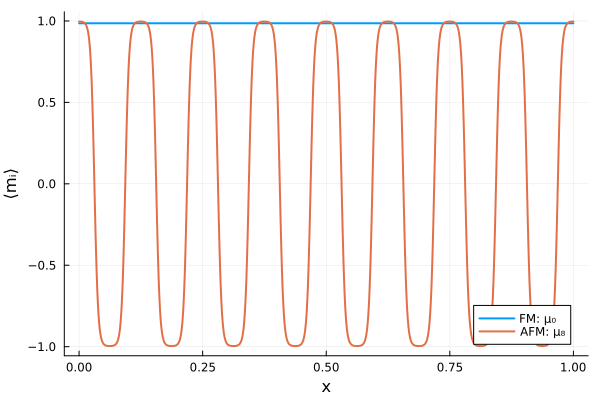

In [28]:
# Small-world profiles corresponding to Fig. 6(a,b)
# Requires the definitions from IsingGraphonMonteCarlo_Optimized.ipynb.

p = 0.05
r = 0.10
N_profile = 5000          # Set to 5000 for the manuscript-scale calculation
nu_profile = 1000           # Set to 1 for the ordinary, non-replicated Ising model
temperature_offset = 0.6 # T = (1-offset) Tc

burn_sweeps = 5000
measurement_sweeps = 5000
thin = 1
seed_profile = 20260830

x = midpoint_grid(N_profile)
W_sw = small_world_kernel(N_profile, p, r)
coupling_sw = matrix_coupling(W_sw; symmetrize=false)

# Small-world graphon eigenvalues
mu0 = 2r * (1 - 2p) + p
mu(k) = (1 - 2p) * sin(2π * k * r) / (π * k)
mu8 = mu(8)

# ------------------------------------------------------------
# Ferromagnetic mode: J = +1, Tc = J*mu0
# ------------------------------------------------------------

J_FM = 1.0
T_FM = (1 - temperature_offset) * J_FM * mu0
reference_FM = ones(N_profile)

model_FM = ReplicatedGraphonIsing(
    coupling_sw;
    nu=nu_profile,
    J=J_FM,
    T=T_FM,
    convention=:manuscript,
    init=:plus,
    seed=seed_profile,
)

result_FM = run_chain!(
    model_FM;
    algorithm=:heatbath,
    burn_sweeps=burn_sweeps,
    samples=measurement_sweeps,
    thin=thin,
    reference=reference_FM,
)

# ------------------------------------------------------------
# Antiferromagnetic k=8 mode: J = -1, Tc = J*mu8 > 0
# ------------------------------------------------------------

J_AFM = -1.0
T_AFM = (1 - temperature_offset) * J_AFM * mu8

reference_AFM = cos.(2π * 8 .* x)
initial_AFM = ifelse.(reference_AFM .>= 0.0, 1.0, -1.0)

model_AFM = ReplicatedGraphonIsing(
    coupling_sw;
    nu=nu_profile,
    J=J_AFM,
    T=T_AFM,
    convention=:manuscript,
    init=initial_AFM,
    seed=seed_profile + 1,
)

result_AFM = run_chain!(
    model_AFM;
    algorithm=:heatbath,
    burn_sweeps=burn_sweeps,
    samples=measurement_sweeps,
    thin=thin,
    reference=reference_AFM,
)

# ------------------------------------------------------------
# Save sign-aligned local magnetization profiles
# Columns: node index, x_i, <m_i>_MC, final m_i, reference mode
# ------------------------------------------------------------

function write_profile_csv(filename, x, result, reference)
    data = hcat(
        collect(eachindex(x)),
        x,
        result.local_mean,
        result.final_local_magnetization,
        reference,
    )

    open(filename, "w") do io
        println(io, "node,x,m_mean,m_final,reference_mode")
        writedlm(io, data, ',')
    end
end

fm_file = "small_world_FM_mu0_profile.csv"
afm_file = "small_world_AFM_mu8_profile.csv"

write_profile_csv(fm_file, x, result_FM, reference_FM)
write_profile_csv(afm_file, x, result_AFM, reference_AFM)

@printf("mu0 = %.8f, T_FM = %.8f\n", mu0, T_FM)
@printf("mu8 = %.8f, T_AFM = %.8f\n", mu8, T_AFM)
println("Saved: ", fm_file)
println("Saved: ", afm_file)

# Optional visualization
if HAS_PLOTS
    plot(
        x,
        result_FM.local_mean;
        lw=2,
        label="FM: μ₀",
        xlabel="x",
        ylabel="⟨mᵢ⟩",
    )
    plot!(
        x,
        result_AFM.local_mean;
        lw=2,
        label="AFM: μ₈",
    )
end

## Production checklist

1. Run the deterministic tests.
2. Choose whether the coupling is the deterministic \(W^n\), a sampled
   adjacency matrix, or the rescaled sparse power-law realization.
3. Use `:heatbath` for replica simulations; use `:metropolis` when an exact
   match to the manuscript's stated proposal mechanism is specifically
   required.
4. Increase burn-in until traces are stationary. Increase `thin` and the
   sample count until the effective sample size is satisfactory.
5. For a metastable higher mode, initialize with `sign.(eigenvector)` and
   pass the same vector as `reference`; do not average profiles without
   sign alignment.
6. Use several independent seeds near a transition or inside a metastable
   regime. Parallelize those independent chains, not updates within a chain.
